In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


%matplotlib inline


sns.set_style("whitegrid")

In [6]:
df = pd.read_csv("../data/diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [7]:
print("Rows and Columns:", df.shape)
df.columns

Rows and Columns: (768, 9)


Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [9]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [10]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df["Outcome"].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

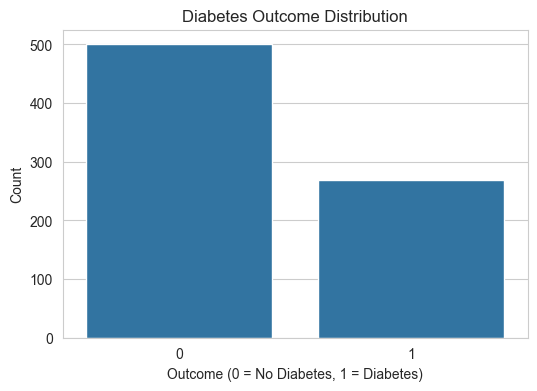

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(x="Outcome", data=df)

plt.title("Diabetes Outcome Distribution")
plt.xlabel("Outcome (0 = No Diabetes, 1 = Diabetes)")
plt.ylabel("Count")
plt.show()

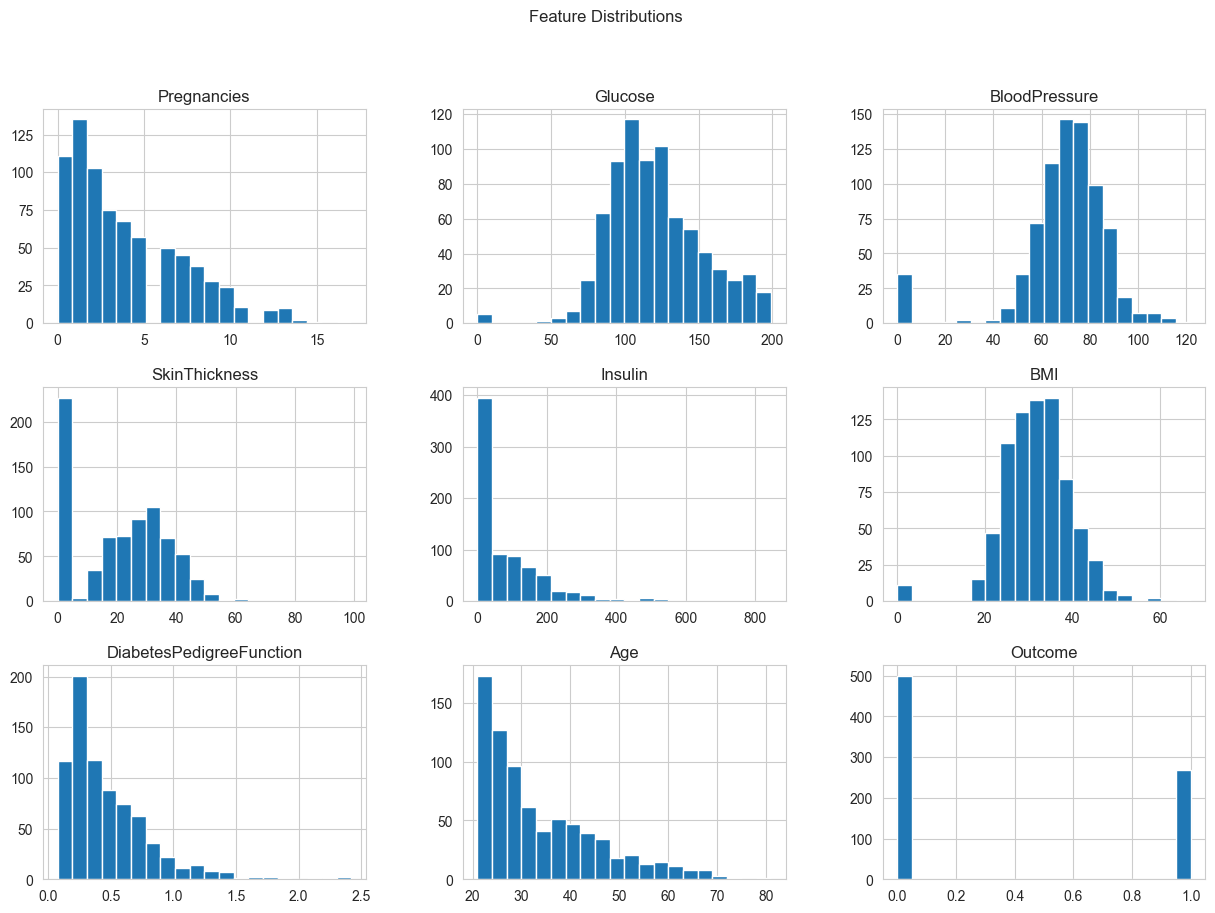

In [14]:
df.hist(figsize=(15,10), bins=20)
plt.suptitle("Feature Distributions")
plt.show()

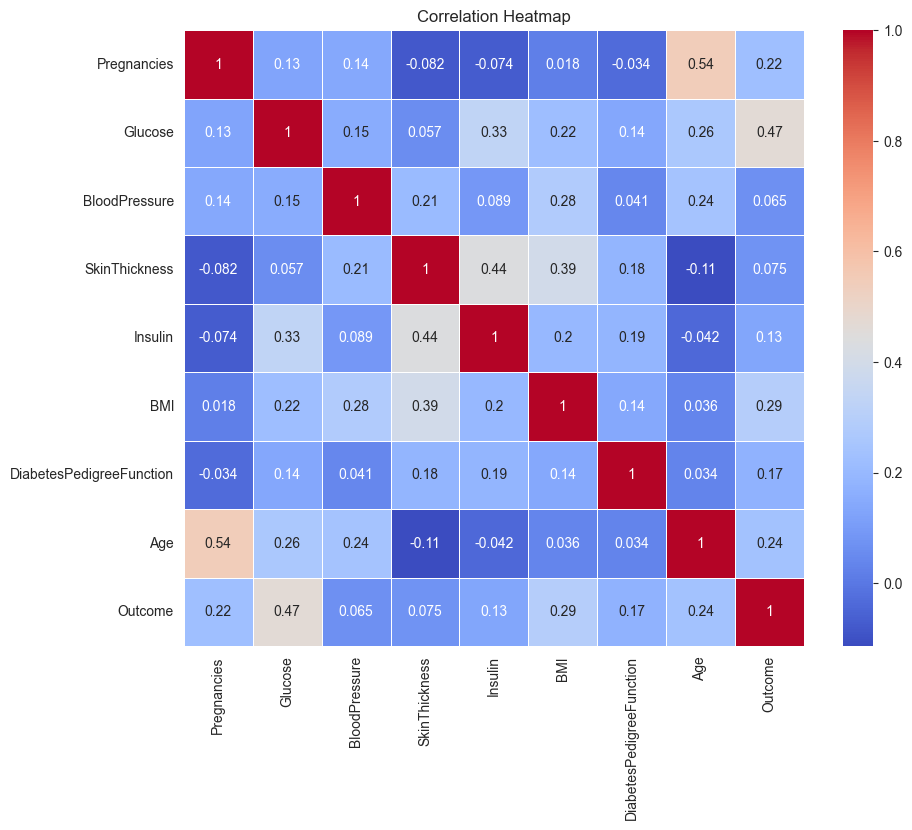

In [15]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

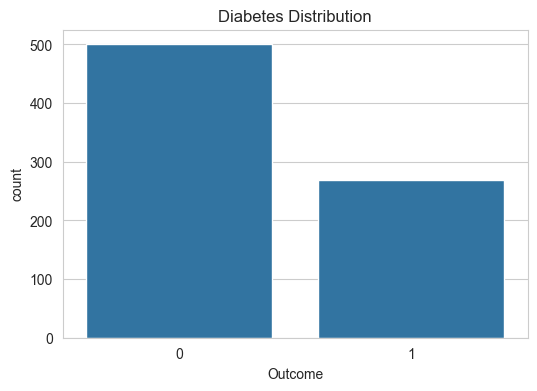

In [16]:
plt.figure(figsize=(6,4))

sns.countplot(x="Outcome", data=df)

plt.title("Diabetes Distribution")
plt.show()

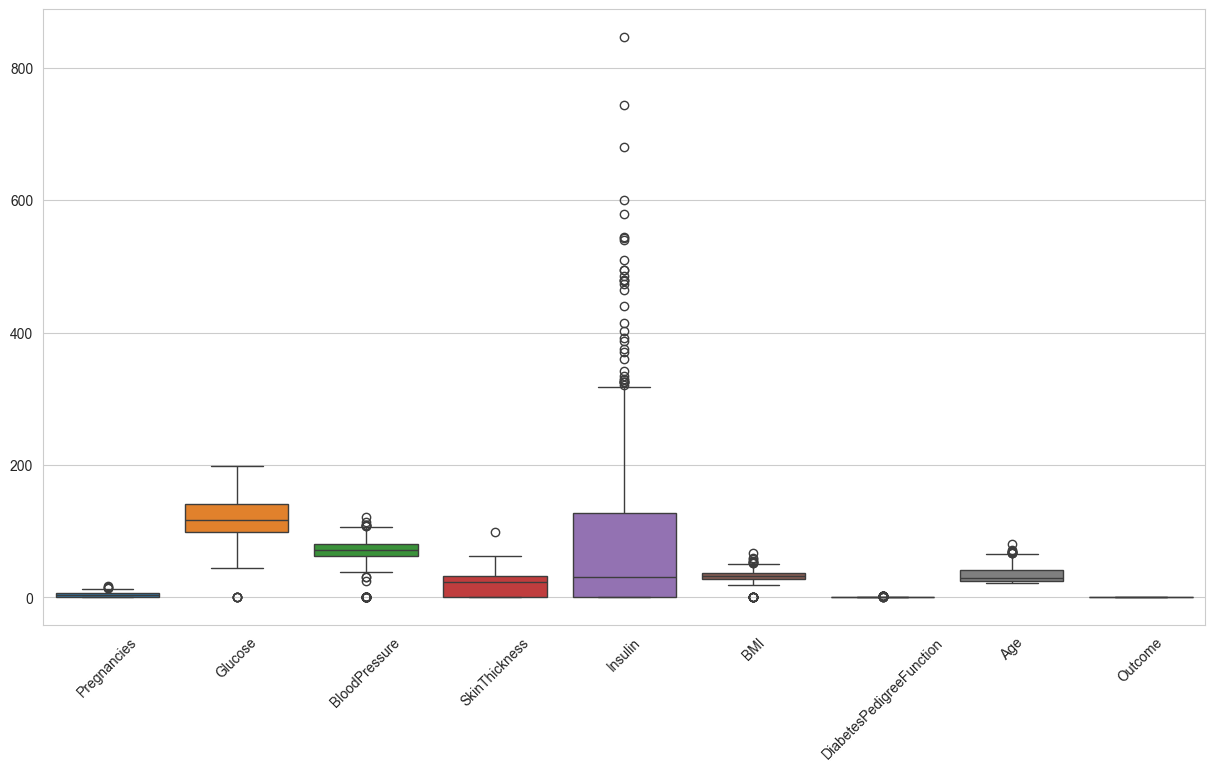

In [17]:
plt.figure(figsize=(15,8))

sns.boxplot(data=df)

plt.xticks(rotation=45)

plt.show()

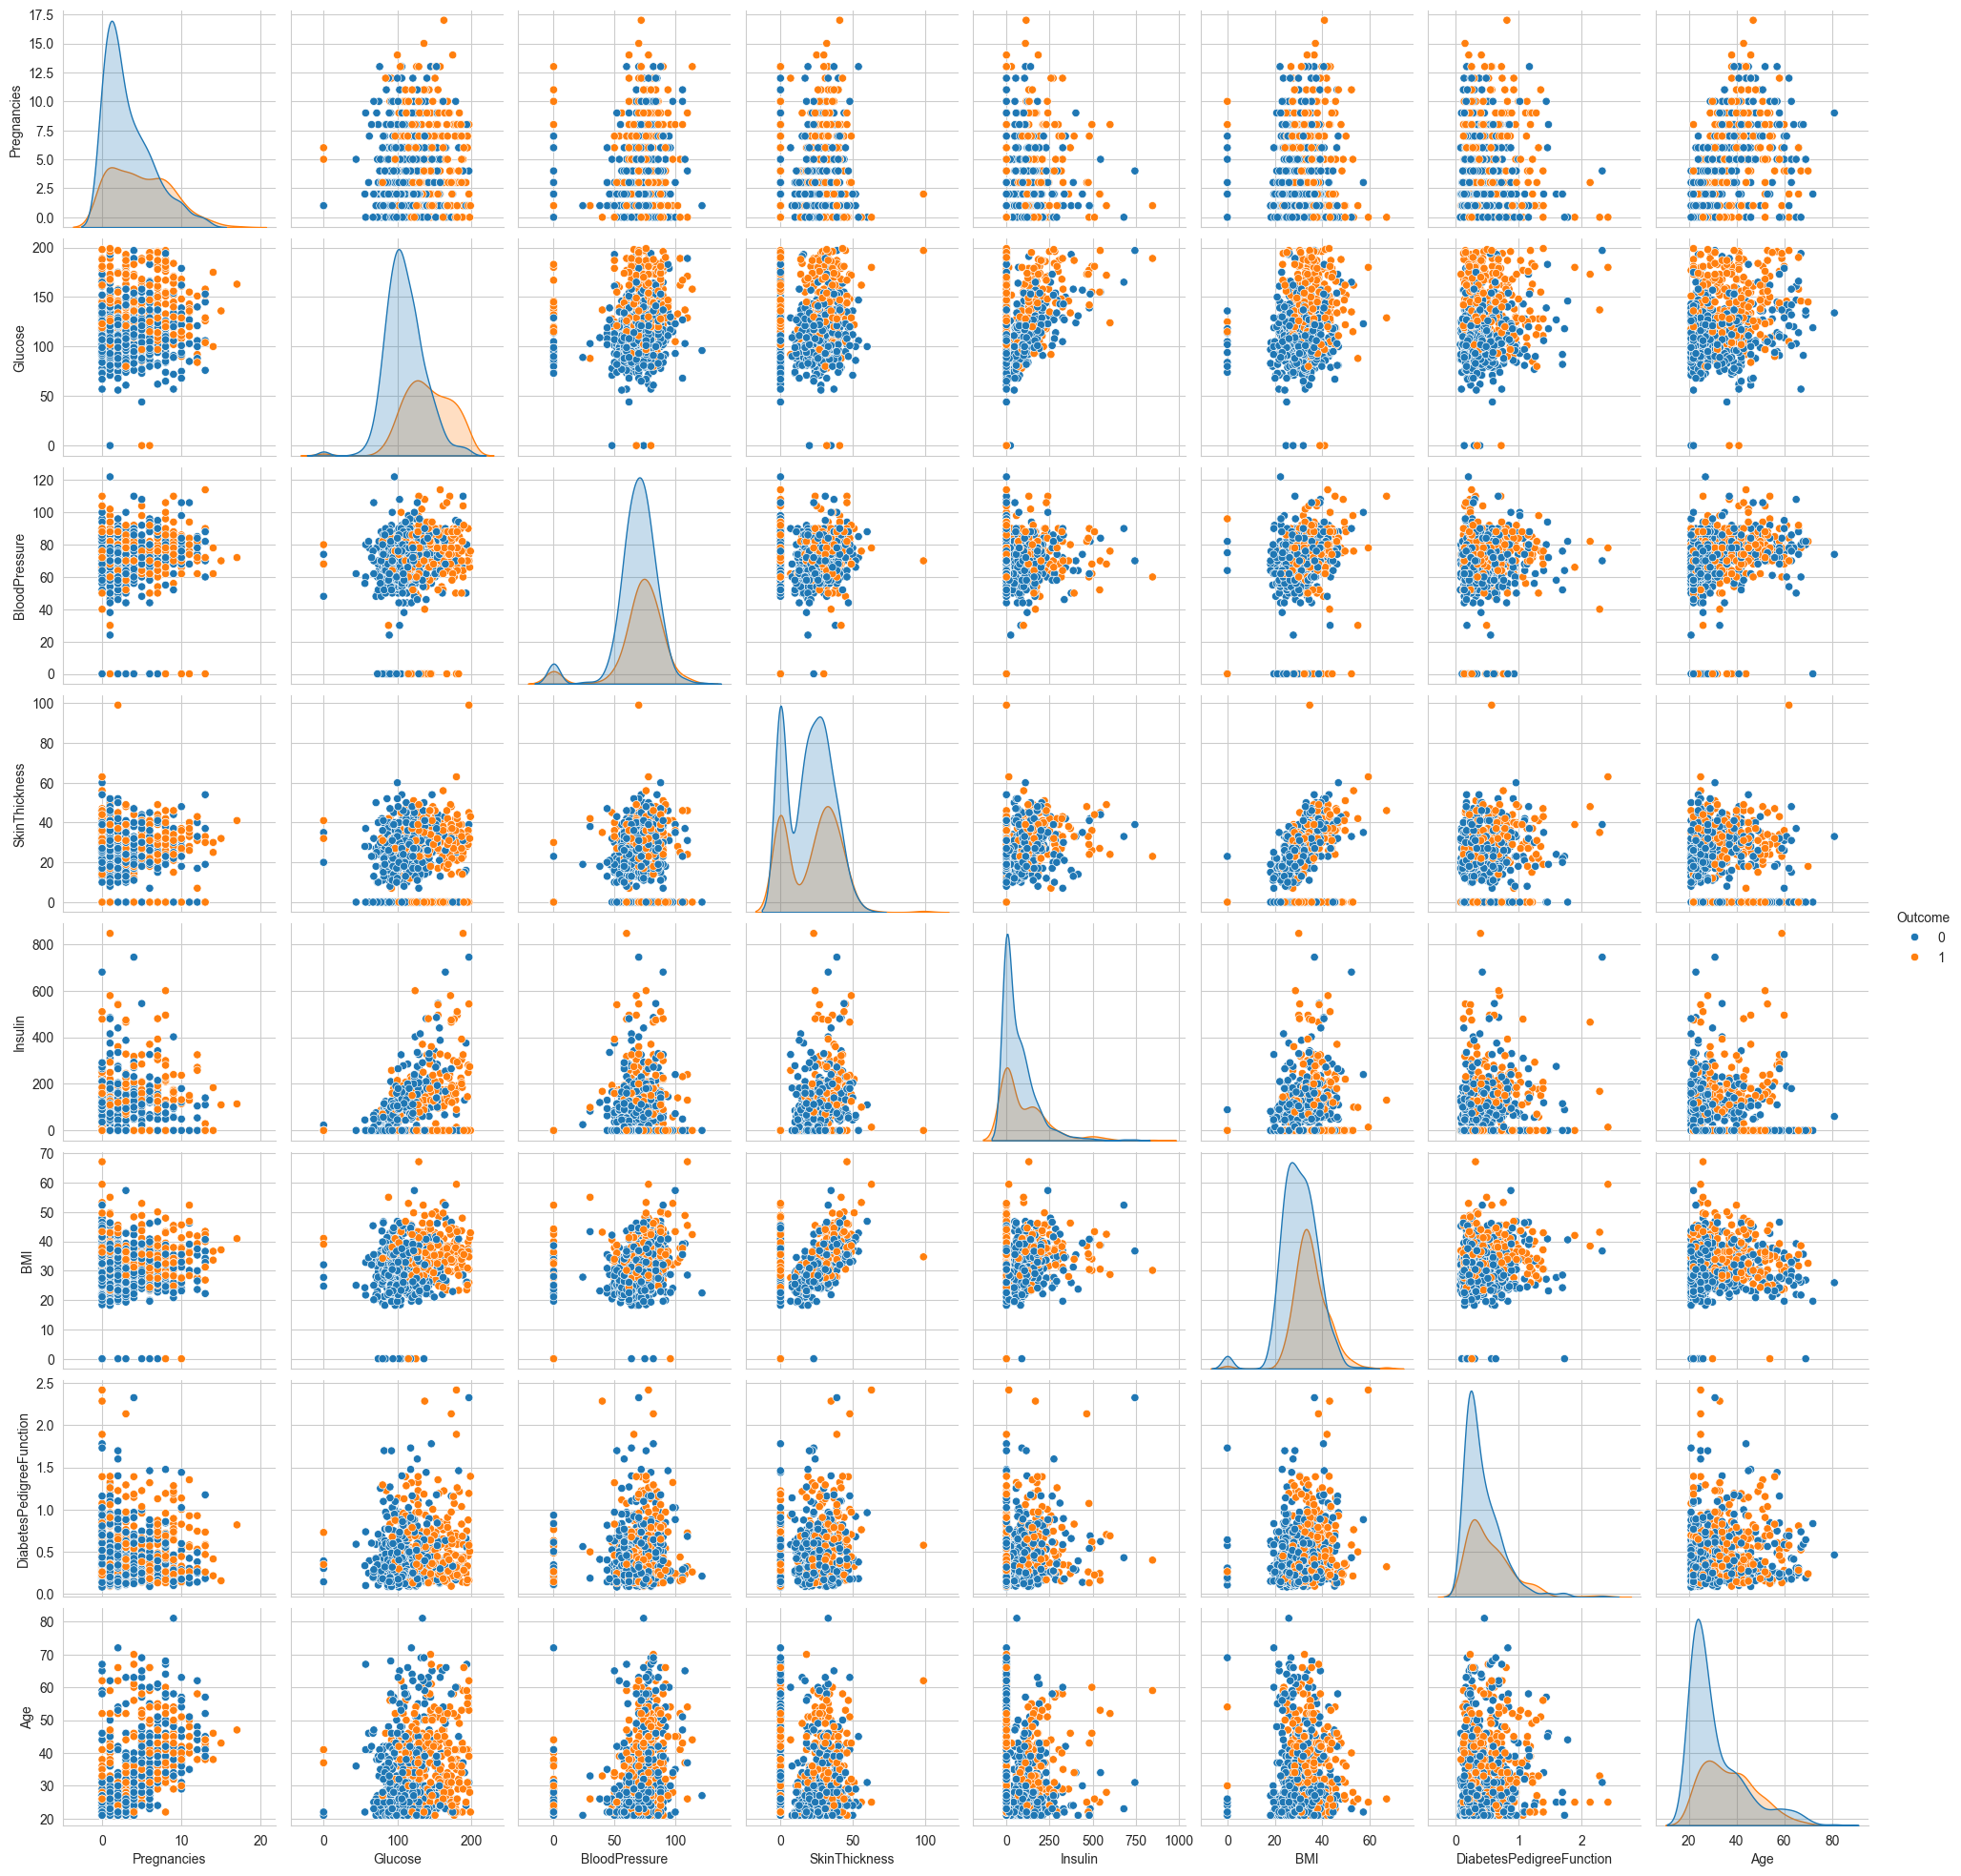

In [18]:
sns.pairplot(df, hue="Outcome")
plt.show()

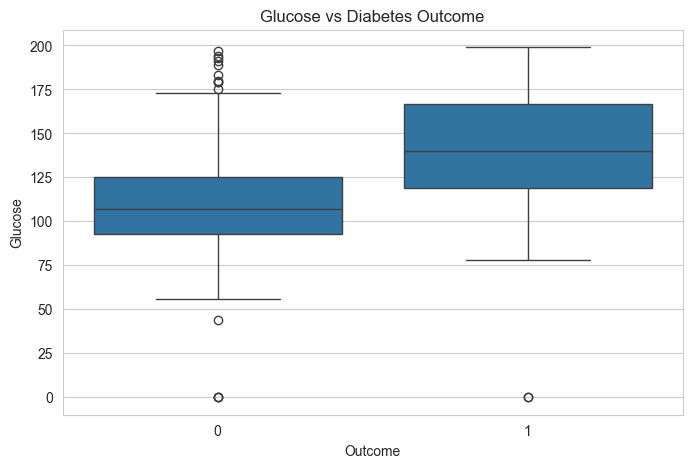

In [19]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Outcome", y="Glucose", data=df)

plt.title("Glucose vs Diabetes Outcome")

plt.show()

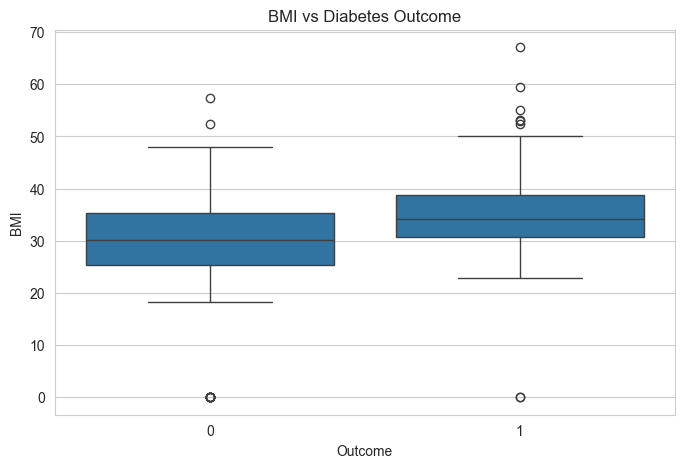

In [20]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Outcome", y="BMI", data=df)

plt.title("BMI vs Diabetes Outcome")

plt.show()

In [21]:
df_fe = df.copy()
zero_columns = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

for col in zero_columns:
    print(f"{col}: {(df_fe[col] == 0).sum()} zero values")

Glucose: 5 zero values
BloodPressure: 35 zero values
SkinThickness: 227 zero values
Insulin: 374 zero values
BMI: 11 zero values


In [22]:
for col in zero_columns:
    median = df_fe[df_fe[col] != 0][col].median()
    df_fe[col] = df_fe[col].replace(0, median)


In [23]:
for col in zero_columns:
    print(f"{col}: {(df_fe[col] == 0).sum()} zero values")

Glucose: 0 zero values
BloodPressure: 0 zero values
SkinThickness: 0 zero values
Insulin: 0 zero values
BMI: 0 zero values


In [24]:
def bmi_category(bmi):
    if bmi < 18.5:
        return "Underweight"
    elif bmi < 25:
        return "Normal"
    elif bmi < 30:
        return "Overweight"
    else:
        return "Obese"

df_fe["BMI_Category"] = df_fe["BMI"].apply(bmi_category)
df_fe[["BMI", "BMI_Category"]].head()

,BMI,BMI_Category
0,33.6,Obese
1,26.6,Overweight
2,23.3,Normal
3,28.1,Overweight
4,43.1,Obese


In [25]:
bmi_map = {
    "Underweight": 0,
    "Normal": 1,
    "Overweight": 2,
    "Obese": 3
}

df_fe["BMI_Category"] = df_fe["BMI_Category"].map(bmi_map)

In [26]:
df_fe.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,BMI_Category
0,6,148,72,35,125,33.6,0.627,50,1,3
1,1,85,66,29,125,26.6,0.351,31,0,2
2,8,183,64,29,125,23.3,0.672,32,1,1
3,1,89,66,23,94,28.1,0.167,21,0,2
4,0,137,40,35,168,43.1,2.288,33,1,3


In [27]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [29]:
X = df_fe.drop("Outcome", axis=1)
y = df_fe["Outcome"]
print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (768, 9)
Target Shape: (768,)


In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [31]:
print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (614, 9)
Testing Data: (154, 9)


In [33]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [35]:
import pandas as pd

X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X.columns
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X.columns
)
X_train_scaled.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,BMI_Category
0,-0.851355,-1.056427,-0.826740,-1.918187,-1.203361,-0.769477,0.310794,-0.792169,-0.661062
1,0.356576,0.144399,0.477772,-0.229874,-1.470195,-0.417498,-0.116439,0.561034,-0.661062
2,-0.549372,-0.556083,-1.152868,1.233330,-0.555335,0.359790,-0.764862,-0.707594,0.691912
3,-0.851355,0.811525,-1.315932,-0.004766,-0.161437,-0.402832,0.262314,-0.369293,-0.661062
4,-1.153338,-0.889646,-0.663676,1.120776,-0.415565,1.782373,-0.337630,-0.961320,0.691912


In [36]:
import joblib

joblib.dump(scaler, "../models/scaler.pkl")

['../models/scaler.pkl']

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

In [38]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True, random_state=42)
}

In [39]:
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    print(f"{name} Trained Successfully")

Logistic Regression Trained Successfully
Decision Tree Trained Successfully
Random Forest Trained Successfully
KNN Trained Successfully
SVM Trained Successfully


In [42]:
predictions = {}

for name, model in models.items():
    predictions[name] = model.predict(X_test_scaled)
   

In [43]:
predictions["Random Forest"][:10]

array([1, 0, 0, 0, 0, 0, 0, 1, 0, 1])

In [44]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import pandas as pd

In [ ]:
results = []

for name, model in models.items():

    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    })
    

In [47]:
results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.701299,0.586957,0.500000,0.540000,0.820000
1,Decision Tree,0.701299,0.586957,0.500000,0.540000,0.655000
2,Random Forest,0.740260,0.652174,0.555556,0.600000,0.817407
3,KNN,0.753247,0.681818,0.555556,0.612245,0.784630
4,SVM,0.740260,0.659091,0.537037,0.591837,0.800741


In [51]:
results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
3,KNN,0.753247,0.681818,0.555556,0.612245,0.784630
4,SVM,0.740260,0.659091,0.537037,0.591837,0.800741
2,Random Forest,0.740260,0.652174,0.555556,0.600000,0.817407
0,Logistic Regression,0.701299,0.586957,0.500000,0.540000,0.820000
1,Decision Tree,0.701299,0.586957,0.500000,0.540000,0.655000


In [52]:

best_model_name = results_df.iloc[0]["Model"]

print("Best Model:", best_model_name)

Best Model: KNN


In [53]:
best_model = models[best_model_name]

y_pred = best_model.predict(X_test_scaled)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.78      0.86      0.82       100
           1       0.68      0.56      0.61        54

    accuracy                           0.75       154
   macro avg       0.73      0.71      0.72       154
weighted avg       0.75      0.75      0.75       154



In [54]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[86 14]
 [24 30]]


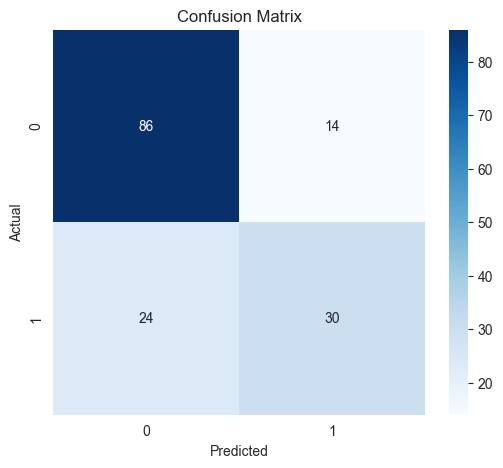

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [62]:
import joblib
print(best_model_name)
joblib.dump(best_model, "../models/diabetes_model.pkl")
joblib.dump(scaler, "../models/scaler.pkl")

KNN


['../models/scaler.pkl']

In [63]:
feature_names = X.columns.tolist()

joblib.dump(feature_names, "../models/feature_names.pkl")

['../models/feature_names.pkl']

In [64]:
import os

print(os.listdir("../models"))

['diabetes_model.pkl', 'feature_names.pkl', 'scaler.pkl']


In [65]:
print(X.columns)
print(X.shape)

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'BMI_Category'],
      dtype='object')
(768, 9)
